# plot time shift radars
time shift between grawac and ship, the correlation gives a shift parameter in seconds that should be applied to the grawac data to align the two. how does that shift change with time, how many gaps are there in the shifts (because only times with significant roll have been taken to calculate correlation), and how does the shift compare to mirac-a? all that is plotted here

In [94]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob
import datetime
import xarray as xr
import matplotlib.dates as md
from sklearn.linear_model import LinearRegression
import pytz

In [ ]:
shift = pd.read_csv('VAMPIRE_grawac_20240813_20241010.txt', sep=',',header=0)

,Unnamed: 0,time,shift_grawac_roll_COM,shift_grawac_roll_hydrins
0,0,2024-08-13 21:00:00,-0.05,-0.15
1,1,2024-08-13 22:00:00,-0.15,-0.20
2,2,2024-08-14 00:00:00,-0.35,-0.45
3,3,2024-08-14 01:00:00,-0.20,-0.20
4,4,2024-08-14 02:00:00,-0.65,-0.75
...,...,...,...,...
835,835,2024-10-07 13:00:00,8.15,2.50
836,836,2024-10-07 14:00:00,8.15,2.45
837,837,2024-10-07 15:00:00,8.00,2.40
838,838,2024-10-07 21:00:00,7.35,1.60


In [87]:
shift['datetime'] = np.array([datetime.datetime.strptime(shift.time[i], '%Y-%m-%d %H:%M:%S')
 for i in range(len(shift['time']))])

In [88]:
result = shift['shift_grawac_roll_hydrins'].to_numpy().nonzero()
shiftnonzero = shift['shift_grawac_roll_hydrins'].iloc[result]

newshift = shift.iloc[result]

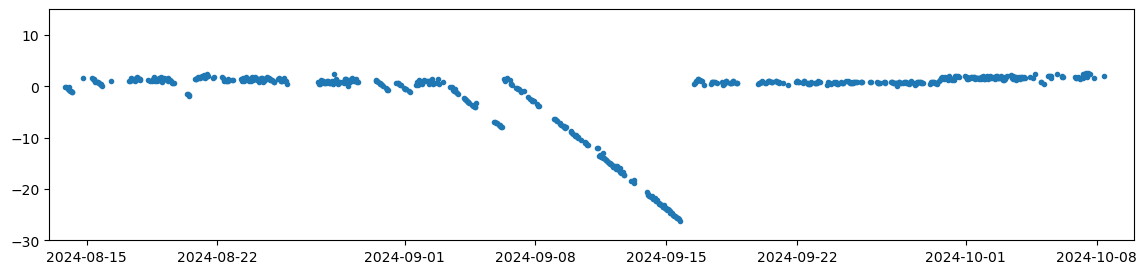

In [183]:
plt.plot(newshift.datetime, newshift.shift_grawac_roll_hydrins, '.')
plt.rcParams["figure.figsize"] = (14,3)
plt.ylim(-30,15)
plt.xlim(datetime.datetime(2024,8,13),datetime.datetime(2024,10,10))
plt.savefig('VAMPIRE1/shift_VAMPIRE1_nonzero.png')

In [89]:
df = newshift.set_index(['datetime'])
df = df[(df["shift_grawac_roll_hydrins"] > -50)]
df['datetime'] = df.index
model = LinearRegression()

In [23]:
def get_shiftperhour(starttime,endtime,ymin,ymax):
    index = df['Unnamed: 0'].loc['%s-%s-%s %s:00:00'%(starttime.year,starttime.month,starttime.day,starttime.hour):'%s-%s-%s %s:00:00'%(endtime.year,endtime.month,endtime.day,endtime.hour)].values
    angles = df.shift_grawac_roll_hydrins.loc['%s-%s-%s %s:00:00'%(starttime.year,starttime.month,starttime.day,starttime.hour):'%s-%s-%s %s:00:00'%(endtime.year,endtime.month,endtime.day,endtime.hour)].values
    time = df['datetime']['%s-%s-%s %s:00:00'%(starttime.year,starttime.month,starttime.day,starttime.hour):'%s-%s-%s %s:00:00'%(endtime.year,endtime.month,endtime.day,endtime.hour)].values
    angles = angles.reshape(len(angles), 1)
    index = index.reshape(len(angles),1)
    time = time.reshape(len(time),1)
    model.fit(index, angles)
    #fig, plt = plt.figure()
    #fmt = md.DateFormatter('%H:%M:%S')
    plt.scatter(time,angles,  color='black')
    #plt.plot(time, model.predict(index), color='blue', linewidth=3)
    plt.plot([time[0],time[-1]],[angles[0],angles[-1]],color='red')
    plt.ylabel('shift in s')
    plt.ylim(ymin,ymax)
    plt.savefig('regression_timelag_%s_%s.png'%(str(starttime),str(endtime)))
    #plt.rcParams["date.autoformatter.minute"] = "%Y-%m-%d %H:%M:%S"
    #plt.gca().xaxis.set_major_formatter(fmt)
    diff = endtime-starttime
    hours = diff.seconds//3600+diff.days*24
    shiftperhour = (angles[-1]-angles[0])/hours
    return model.coef_, shiftperhour

In [16]:
def get_shiftstrait(starttime,endtime,df):
    #df.shift_grawac_roll_hydrins.loc['2024-9-6 23:00:00':'2024-9-15 17:00:00']
    df = df[(df["shift_grawac_roll_hydrins"] < 15)]
    index = df['Unnamed: 0'].loc['%s-%s-%s %s:00:00'%(starttime.year,starttime.month,starttime.day,starttime.hour):'%s-%s-%s %s:00:00'%(endtime.year,endtime.month,endtime.day,endtime.hour)].values
    angles = df.shift_grawac_roll_hydrins.loc['%s-%s-%s %s:00:00'%(starttime.year,starttime.month,starttime.day,starttime.hour):'%s-%s-%s %s:00:00'%(endtime.year,endtime.month,endtime.day,endtime.hour)].values
    time = df['datetime']['%s-%s-%s %s:00:00'%(starttime.year,starttime.month,starttime.day,starttime.hour):'%s-%s-%s %s:00:00'%(endtime.year,endtime.month,endtime.day,endtime.hour)].values
    angles = angles.reshape(len(angles), 1)
    index = index.reshape(len(angles),1)
    time = time.reshape(len(time),1)
    meanshift = np.mean(angles)
    model.fit(index, angles)
    #fig, plt = plt.figure()
    #fmt = md.DateFormatter('%H:%M:%S')
    plt.scatter(time,angles,  color='black')
    #plt.plot(time, model.predict(index), color='blue', linewidth=3)
    plt.hlines(meanshift,xmin=time[0],xmax=time[-1],color='red')
    plt.ylabel('shift in s')
    plt.savefig('regression_timelag_%s_%s.png'%(str(starttime),str(endtime)))
    #plt.rcParams["date.autoformatter.minute"] = "%Y-%m-%d %H:%M:%S"
    #plt.gca().xaxis.set_major_formatter(fmt)
    print(time[-1])
    return model.coef_, meanshift

In [172]:
def slope(starttime,endtime,df):
    index = df['Unnamed: 0'].loc['%s-%s-%s %s:00:00'%(starttime.year,starttime.month,starttime.day,starttime.hour):'%s-%s-%s %s:00:00'%(endtime.year,endtime.month,endtime.day,endtime.hour)].values
    angles = df.shift_grawac_roll_hydrins.loc['%s-%s-%s %s:00:00'%(starttime.year,starttime.month,starttime.day,starttime.hour):'%s-%s-%s %s:00:00'%(endtime.year,endtime.month,endtime.day,endtime.hour)].values
    time = df['datetime']['%s-%s-%s %s:00:00'%(starttime.year,starttime.month,starttime.day,starttime.hour):'%s-%s-%s %s:00:00'%(endtime.year,endtime.month,endtime.day,endtime.hour)].values
    angles = angles.reshape(len(angles), 1)
    index = index.reshape(len(angles),1)
    time = time.reshape(len(time),1)
    ts1 = datetime.datetime(starttime.year,starttime.month,starttime.day,starttime.hour).timestamp()
    ts2 = datetime.datetime(endtime.year,endtime.month,endtime.day,endtime.hour).timestamp()
    model.fit(index, angles)
    m = (angles[-1]-angles[0])/(ts2-ts1)
    b = angles[0]-m*ts1

    dfr = {}
    dfr['timestamp'], dfr['timeshift'], dfr['datetime'] = [], [], []
    for times in range(int(ts1),int(ts2),3600):
        y = m*times + b
        dfr['timeshift'] = np.append(dfr['timeshift'],y[0])
        dfr['timestamp'] = np.append(dfr['timestamp'],times)
        dfr['datetime'] = np.append(dfr['datetime'],datetime.datetime.utcfromtimestamp(times))
    #print(dfr['datetime'],dfr['timestamp'],dfr['timeshift'])
    return m, b, pd.DataFrame(dfr)

[[-0.23572924]] [-0.11865672]


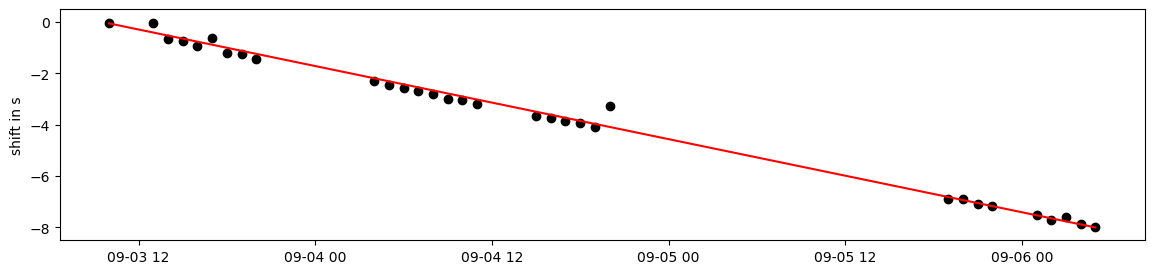

In [173]:
#small shift (3.9. until 6.9.)
#df.shift_grawac_roll_hydrins.loc['2024-9-3 10:00:00':'2024-9-6 05:00:00']
starttimesmall=datetime.datetime(2024,9,3,10)
endtimesmall=datetime.datetime(2024,9,6,5)
modelcoeff, hourshiftsmall = get_shiftperhour(starttimesmall,endtimesmall,-8.5,0.5)
m, b, dfsmall = slope(starttimesmall,endtimesmall,df)
print(modelcoeff,hourshiftsmall)

[[-0.41938402]] [-0.12222222]


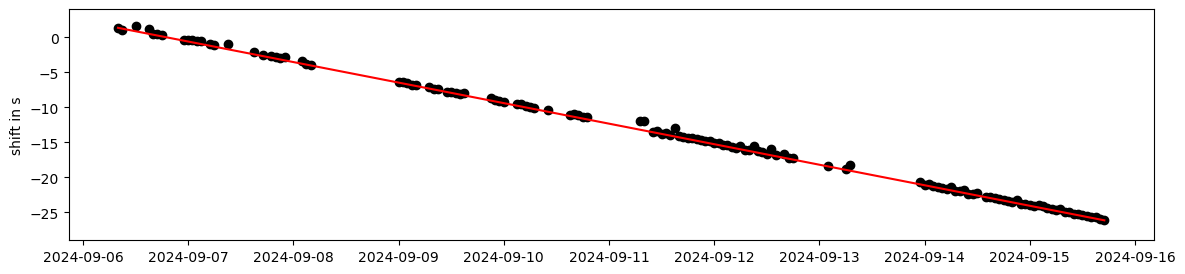

In [175]:
#big shift (6.9. until 15.9.)
#df.shift_grawac_roll_hydrins.loc['2024-9-6 08:00:00':'2024-9-15 17:00:00']
starttimebig=datetime.datetime(2024,9,6,8)
endtimebig=datetime.datetime(2024,9,15,17)
modelcoeff, hourshiftbig = get_shiftperhour(starttimebig,endtimebig,-29,4)
m, b, dfbig = slope(starttimebig,endtimebig,df)
print(modelcoeff,hourshiftbig)

[[-0.68447368]] [-0.19705882]


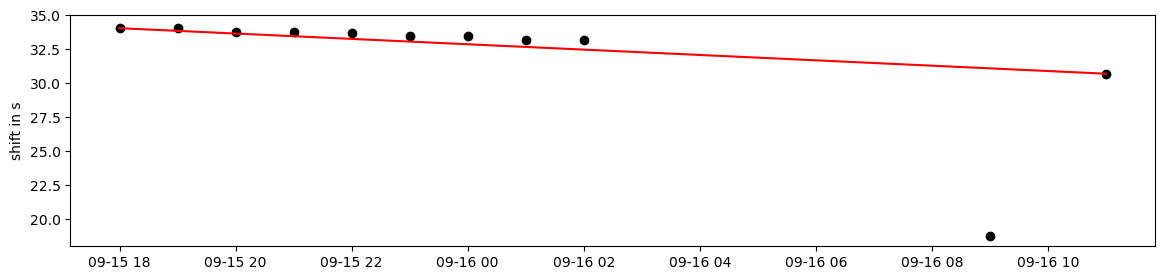

In [176]:
#after big shift (15.9. until 16.9.)
df.shift_grawac_roll_hydrins.loc['2024-9-15 18:00:00':'2024-9-16 11:00:00']
starttimeafter=datetime.datetime(2024,9,15,18)
endtimeafter=datetime.datetime(2024,9,16,11)
modelcoeff,hourshiftafter = get_shiftperhour(starttimeafter,endtimeafter,18,35)
m, b, dfafter = slope(starttimeafter,endtimeafter,df)
print(modelcoeff,hourshiftafter)

['2024-09-29T11:00:00.000000000']
[[-0.0009371]] 0.7287878787878788


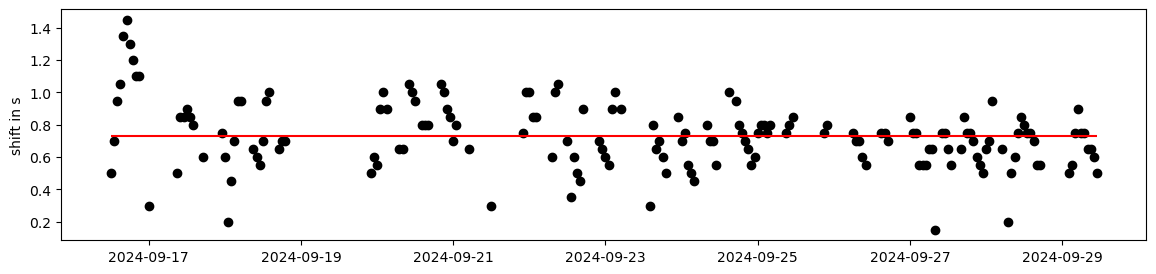

In [177]:
#september straight 1 (16.9. until 29.9.)
#df.shift_grawac_roll_hydrins.loc['2024-9-16 12:00:00':'2024-9-29 11:00:00']
starttime1=datetime.datetime(2024,9,16,12)
endtime1=datetime.datetime(2024,9,29,11)
modelcoeff, hourshift1 = get_shiftstrait(starttime1,endtime1,df)
m, b, df1= slope(starttime1,endtime1,df)
print(modelcoeff,hourshift1)

['2024-10-08T09:00:00.000000000']
[[0.00249305]] 1.724418604651163


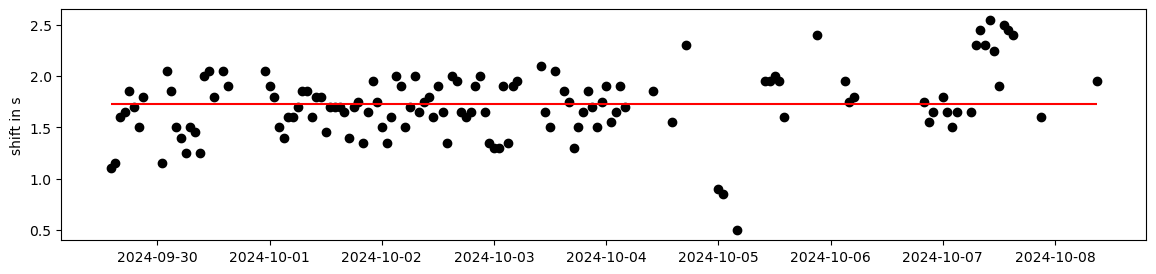

In [178]:
#september straight 2 (29.9. until 8.10.)
df.shift_grawac_roll_hydrins.loc['2024-9-29 12:00:00':'2024-10-8 11:00:00']
starttime2=datetime.datetime(2024,9,29,12)
endtime2=datetime.datetime(2024,10,8,11)
modelcoeff, hourshift2 = get_shiftstrait(starttime2,endtime2,df)
m, b, df2 = slope(starttime2,endtime2,df)
print(modelcoeff,hourshift2)

['2024-09-03T01:00:00.000000000']
[[0.01138799]] 0.8099999999999999


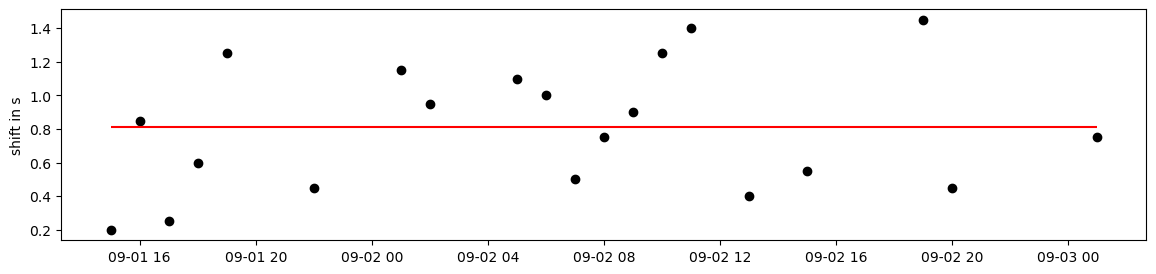

In [193]:
#before small (1.9. 12 until 3.9. 9)
df.shift_grawac_roll_hydrins.loc['2024-9-1 12:00:00':'2024-9-3 9:00:00']
starttimebefore=datetime.datetime(2024,9,1,12)
endtimebefore=datetime.datetime(2024,9,3,9)
modelcoeff, hourshiftbefore = get_shiftstrait(starttimebefore,endtimebefore,df)
m, b, dfbefore = slope(starttimebefore,endtimebefore,df)
print(modelcoeff,hourshiftbefore)

[[-0.11143564]] [-0.09722222]


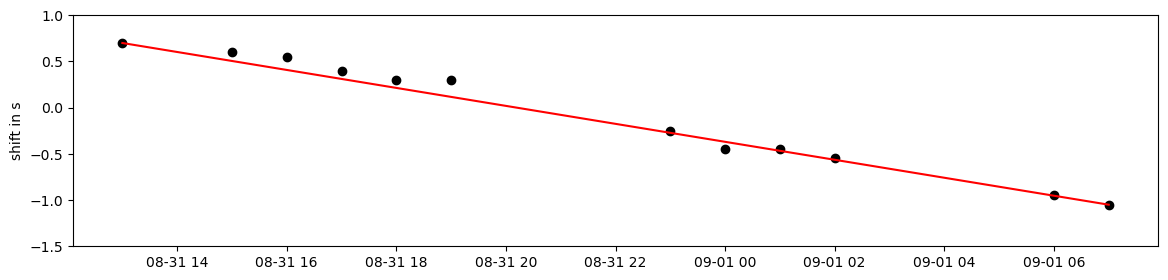

In [226]:
#second small line 
df.shift_grawac_roll_hydrins.loc['2024-8-31 13:00:00':'2024-9-1 7:00:00']
starttimesecs=datetime.datetime(2024,8,31,13)
endtimesecs=datetime.datetime(2024,9,1,7)
modelcoeff, hourshiftsecs = get_shiftperhour(starttimesecs,endtimesecs,-1.5,1)
m, b, dfsecs = slope(starttimesecs,endtimesecs,df)
print(modelcoeff,hourshiftsecs)

[[-0.12374308]] [-0.128125]


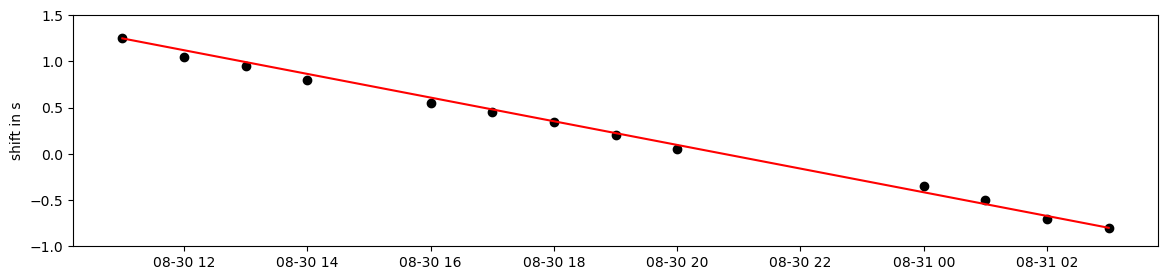

In [254]:
#first small line 
df.shift_grawac_roll_hydrins.loc['2024-8-30 11:00:00':'2024-8-31 3:00:00']
starttimefirs=datetime.datetime(2024,8,30,11)
endtimefirs=datetime.datetime(2024,8,31,3)
modelcoeff, hourshiftfirs = get_shiftperhour(starttimefirs,endtimefirs,-1,1.5)
m, b, dffirs = slope(starttimefirs,endtimefirs,df)
print(modelcoeff,hourshiftfirs)

['2024-08-29T12:00:00.000000000']
[[-0.00697764]] 1.243307086614173


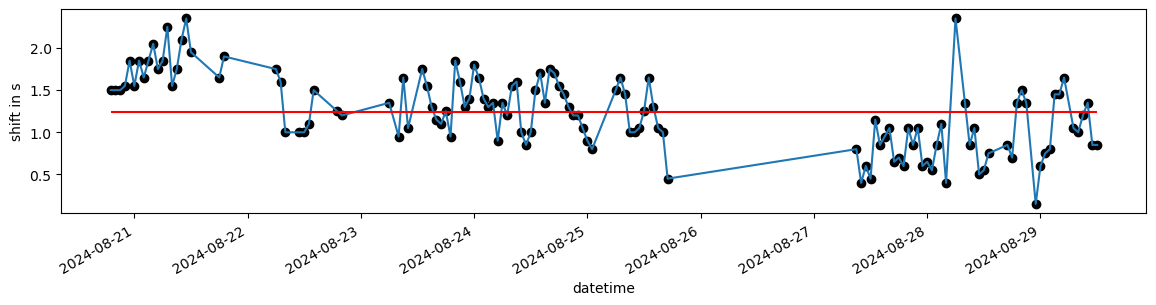

In [ ]:
#second half of august
df.shift_grawac_roll_hydrins.loc['2024-8-20 13:00:00':'2024-8-29 12:00:00'].plot()
starttimeaug=datetime.datetime(2024,8,20,13)
endtimeaug=datetime.datetime(2024,8,29,12)
modelcoeff, hourshiftaug = get_shiftstrait(starttimeaug,endtimeaug,df)
m, b, dfaug = slope(starttimeaug,endtimeaug,df)
print(modelcoeff,hourshiftaug)

[[-0.33253558]] [-0.12407407]


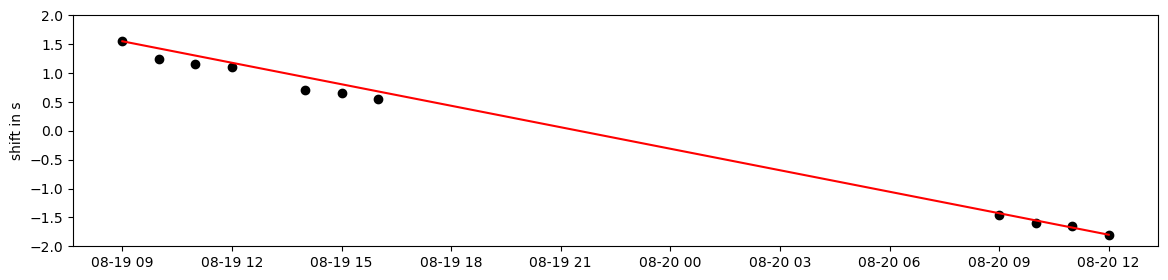

In [293]:
#august line
df.shift_grawac_roll_hydrins.loc['2024-8-19 09:00:00':'2024-8-20 12:00:00']
starttimeaugline=datetime.datetime(2024,8,19,9)
endtimeaugline=datetime.datetime(2024,8,20,12)
modelcoeff, hourshiftaugline = get_shiftperhour(starttimeaugline,endtimeaugline,-2,2)
m, b, dfaugline = slope(starttimeaugline,endtimeaugline,df)
print(modelcoeff,hourshiftaugline)

['2024-08-19T09:00:00.000000000']
[[0.00207074]] 1.3325


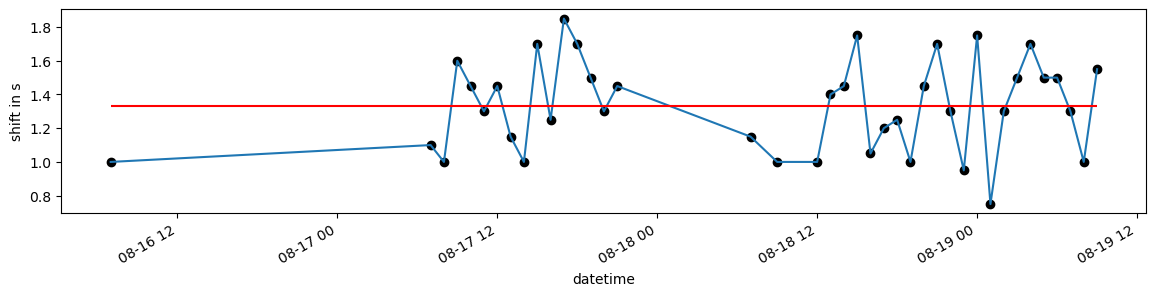

In [327]:
#august beginning
df.shift_grawac_roll_hydrins.loc['2024-8-16 7:00:00':'2024-8-19 9:00:00'].plot()
starttimeaugbegin=datetime.datetime(2024,8,16,7)
endtimeaugbegin=datetime.datetime(2024,8,19,9)
modelcoeff, hourshiftaugbegin = get_shiftstrait(starttimeaugbegin,endtimeaugbegin,df)
m, b, dfaugbegin = slope(starttimeaugbegin,endtimeaugbegin,df)
print(modelcoeff,hourshiftaugbegin)

[[-0.11266234]] [-0.11538462]


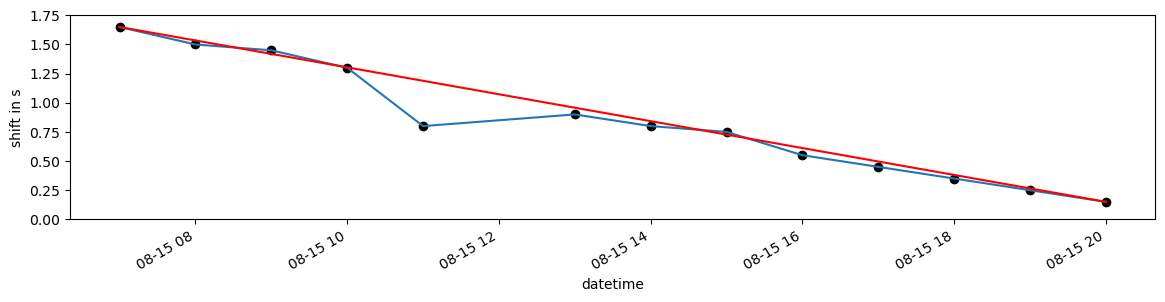

In [315]:
#august beginning line 2
df.shift_grawac_roll_hydrins.loc['2024-8-15 7:00:00':'2024-8-16 0:00:00'].plot()
starttimeaugbeginline2=datetime.datetime(2024,8,15,7)
endtimeaugbeginline2=datetime.datetime(2024,8,15,20)
modelcoeff, hourshiftaugbeginline2 = get_shiftperhour(starttimeaugbeginline2,endtimeaugbeginline2,0,1.75)
m, b, dfaugbeginline2 = slope(starttimeaugbeginline2,endtimeaugbeginline2,df)
print(modelcoeff,hourshiftaugbeginline2)

[[-0.145]] [-0.11666667]


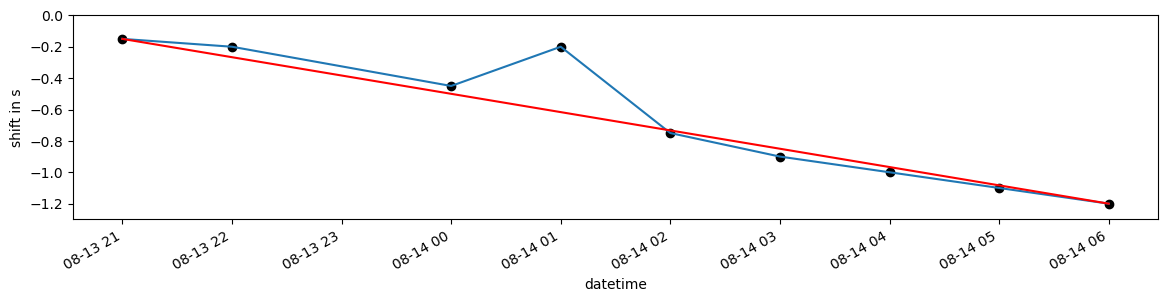

In [320]:
#august beginning line 1
df.shift_grawac_roll_hydrins.loc['2024-8-13 21:00:00':'2024-8-14 6:00:00'].plot()
starttimeaugbeginline1=datetime.datetime(2024,8,13,21)
endtimeaugbeginline1=datetime.datetime(2024,8,14,6)
modelcoeff, hourshiftaugbeginline1 = get_shiftperhour(starttimeaugbeginline1,endtimeaugbeginline1,-1.3,0)
m, b, dfaugbeginline1 = slope(starttimeaugbeginline1,endtimeaugbeginline1,df)
print(modelcoeff,hourshiftaugbeginline1)

In [346]:
dfnew = pd.concat([dfaugbeginline1,dfaugbeginline2,dfaugbegin,dfaugline,dfaug,dffirs,dfsecs,dfbefore,dfsmall,dfbig,dfafter,df1,df2],axis=0)

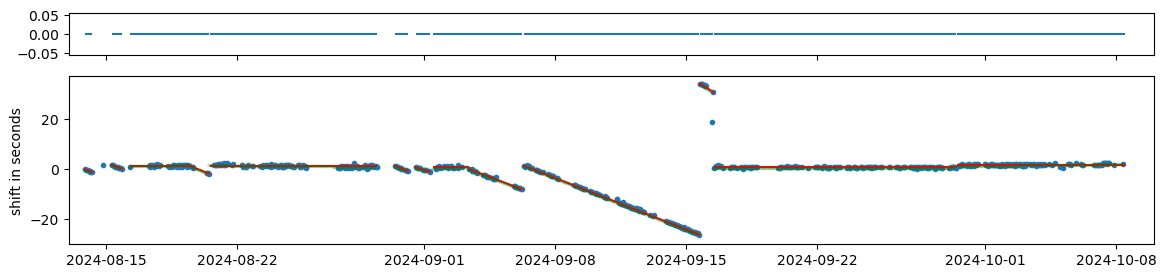

In [342]:
#final parameterizations
fig, ax = plt.subplots(2,sharex=True,gridspec_kw={'height_ratios': [1, 4]})
ax[0].hlines(0, xmin=starttime1,xmax=endtime1)
ax[0].hlines(0, xmin=starttime2,xmax=endtime2)
ax[0].hlines(0, xmin=starttimeafter,xmax=endtimeafter)
ax[0].hlines(0, xmin=starttimesmall,xmax=endtimesmall)
ax[0].hlines(0, xmin=starttimebig,xmax=endtimebig)
ax[0].hlines(0, xmin=starttimebefore, xmax=endtimebefore)
ax[0].hlines(0, xmin=starttimesecs, xmax=endtimesecs)
ax[0].hlines(0, xmin=starttimefirs, xmax=endtimefirs)
ax[0].hlines(0, xmin=starttimeaug, xmax=endtimeaug)
ax[0].hlines(0, xmin=starttimeaugline, xmax=endtimeaugline)
ax[0].hlines(0, xmin=starttimeaugbegin, xmax=endtimeaugbegin)
ax[0].hlines(0, xmin=starttimeaugbeginline2, xmax=endtimeaugbeginline2)
ax[0].hlines(0, xmin=starttimeaugbeginline1, xmax=endtimeaugbeginline1)

ax[1].plot(newshift.datetime, newshift.shift_grawac_roll_hydrins, '.')
#ax[1].rcParams["figure.figsize"] = (14,3)
ax[1].set_ylim(-30,37)
ax[1].set_ylabel('shift in seconds')
ax[1].set_xlim(datetime.datetime(2024,8,13),datetime.datetime(2024,10,10))
ax[1].plot([starttimebig,endtimebig],[df['shift_grawac_roll_hydrins'][(df['datetime'] == starttimebig)], df['shift_grawac_roll_hydrins'][(df['datetime'] == endtimebig)]],color='red')
ax[1].plot([starttimesmall,endtimesmall],[df['shift_grawac_roll_hydrins'][(df['datetime'] == starttimesmall)], df['shift_grawac_roll_hydrins'][(df['datetime'] == endtimesmall)]],color='red')
ax[1].plot([starttimeafter,endtimeafter],[df['shift_grawac_roll_hydrins'][(df['datetime'] == starttimeafter)], df['shift_grawac_roll_hydrins'][(df['datetime'] == endtimeafter)]],color='red')
ax[1].plot([starttimesecs,endtimesecs],[df['shift_grawac_roll_hydrins'][(df['datetime'] == starttimesecs)], df['shift_grawac_roll_hydrins'][(df['datetime'] == endtimesecs)]],color='red')
ax[1].plot([starttimefirs,endtimefirs],[df['shift_grawac_roll_hydrins'][(df['datetime'] == starttimefirs)], df['shift_grawac_roll_hydrins'][(df['datetime'] == endtimefirs)]],color='red')
ax[1].plot([starttimeaugline,endtimeaugline],[df['shift_grawac_roll_hydrins'][(df['datetime'] == starttimeaugline)], df['shift_grawac_roll_hydrins'][(df['datetime'] == endtimeaugline)]],color='red')
ax[1].plot([starttimeaugbeginline2,endtimeaugbeginline2],[df['shift_grawac_roll_hydrins'][(df['datetime'] == starttimeaugbeginline2)], df['shift_grawac_roll_hydrins'][(df['datetime'] == endtimeaugbeginline2)]],color='red')
ax[1].plot([starttimeaugbeginline1,endtimeaugbeginline1],[df['shift_grawac_roll_hydrins'][(df['datetime'] == starttimeaugbeginline1)], df['shift_grawac_roll_hydrins'][(df['datetime'] == endtimeaugbeginline1)]],color='red')
ax[1].hlines(hourshift1,xmin = starttime1,xmax = endtime1,color='red')
ax[1].hlines(hourshift2,xmin = starttime2,xmax = endtime2,color='red')
ax[1].hlines(hourshiftaug,xmin = starttimeaug,xmax = endtimeaug,color='red')
ax[1].hlines(hourshiftaugbegin,xmin = starttimeaugbegin,xmax = endtimeaugbegin,color='red')
ax[1].hlines(hourshiftbefore,xmin = starttimebefore, xmax = endtimebefore, color='red')
ax[1].plot(dfnew['datetime'],dfnew['timeshift'],'.',color='green',alpha=0.1, markersize=3)
#fig.savefig('shift_parameterizations_VAMPIRE1.png')

In [367]:
df.index.names = ['Datetime']

In [369]:
df_all = df.merge(dfnew.drop_duplicates(), on=['datetime'], how='left', indicator=True)

In [385]:
for i in range(0,len(df_all['datetime'])):
    if df_all['_merge'][i] == 'left_only':
        print(df_all['datetime'][i])

2024-08-14 04:00:00
2024-08-14 05:00:00
2024-08-14 06:00:00
2024-08-14 20:00:00
2024-08-15 18:00:00
2024-08-15 19:00:00
2024-08-15 20:00:00
2024-08-20 10:00:00
2024-08-29 10:00:00
2024-08-29 11:00:00
2024-08-29 12:00:00
2024-08-31 01:00:00
2024-08-31 02:00:00
2024-08-31 03:00:00
2024-09-01 06:00:00
2024-09-01 07:00:00
2024-09-06 03:00:00
2024-09-06 04:00:00
2024-09-06 05:00:00
2024-09-15 15:00:00
2024-09-16 09:00:00
2024-09-29 09:00:00
2024-10-08 09:00:00
